Best found at iteration: 12
Number of misclassified points: 33


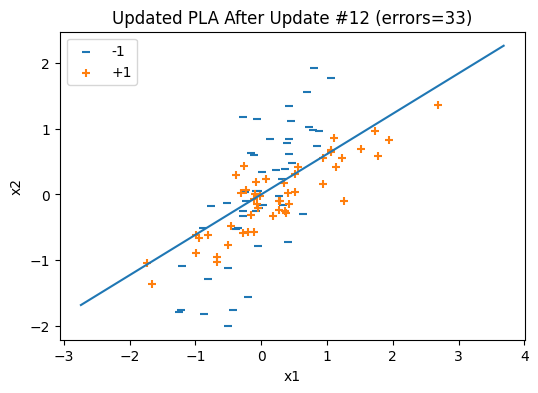

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# ----------------------------
# Data (book-style)
# ----------------------------
N = 100
# random.seed(7)

X, y01 = make_classification(
    n_samples=N,
    n_features=2,
    n_classes=2,
    n_informative=2,
    n_redundant=0,
    n_repeated=0,
    n_clusters_per_class=1,
    class_sep=0.1,        # smaller gap -> can become hard / non-separable in practice
    random_state=5
)

# Convert labels {0,1} -> {-1,+1}
y = y01.copy()
y[y == 0] = -1

# Bias trick: add a column of ones so x = [1, x1, x2]
X_train = np.append(np.ones((N, 1)), X, axis=1)

# ----------------------------
# Helper: classification_error
# ----------------------------
def classification_error(w, X, y):
    s = np.sign(X.dot(w))
    return np.sum(s != y)

# ----------------------------
# Helper: choose_miscl_point
# ----------------------------
def choose_miscl_point(w, X, y):
    mispts = []
    for n in range(len(X)):
        if np.sign(w.T.dot(X[n])) != y[n]:
            mispts.append((X[n], y[n]))
    return mispts[random.randrange(0, len(mispts))]

# ----------------------------
# Updated PLA (Pocket-style)
#  - prevent running forever (max iters)
#  - store best solution ever found
# ----------------------------
w = np.zeros(X_train.shape[1])
it = 0

bestW = {}
bestW['err'] = N + 1
bestW['w']   = []
bestW['it']  = it

# Iterate up to a maximum number of iterations (e.g., 1000)
while it < 100:
    err = classification_error(w, X_train, y)

    # store best-so-far
    if err < bestW['err']:
        bestW['err'] = err
        bestW['it']  = it
        bestW['w']   = list(w)

    # if perfect separation happens, stop early
    if err == 0:
        break

    it += 1
    x_i, s = choose_miscl_point(w, X_train, y)
    w = w + s * x_i

print("Best found at iteration:", bestW['it'])
print("Number of misclassified points:", bestW['err'])

# ----------------------------
# Plot using BEST weights (pocket)
# ----------------------------
w_best = np.array(bestW['w'])

plt.figure(figsize=(6, 4))
plt.scatter(X[y == -1, 0], X[y == -1, 1], marker='_', label='-1')
plt.scatter(X[y == +1, 0], X[y == +1, 1], marker='+', label='+1')

# Decision boundary: w0 + w1*x1 + w2*x2 = 0  -> x2 = -(w0 + w1*x1)/w2
x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

if abs(w_best[2]) < 1e-12:
    # vertical line case
    x_vert = -w_best[0] / w_best[1]
    plt.axvline(x_vert)
else:
    x2_vals = -(w_best[0] + w_best[1] * x1_vals) / w_best[2]
    plt.plot(x1_vals, x2_vals)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"Updated PLA After Update #{bestW['it']} (errors={bestW['err']})")
plt.legend()
plt.show()